## 对比损失函数

In [1]:
import torch
from torch.nn import TripletMarginLoss
#三元损失函数
from PIL import Image
import torchvision.transforms as T
from torch import nn


In [2]:
loss_fn=TripletMarginLoss(margin=2.0,p=2)
#p:范数,2为欧式距离

In [3]:
a=torch.randn(100,5)
p=torch.randn(100,5)
n=torch.randn(100,5)

In [4]:
loss=loss_fn(a,p,n)
#a是锚点,p是正列,n是反列
print(loss)

tensor(2.0933)


## 椒盐噪声

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
np.random.rand()

0.8175274694005202

In [7]:
#定义函数:给图像添加椒盐噪声
def pepper_salt(image,percentage):
    noise_image=image.copy()
    #添加噪声,计算噪声点个数
    noise_num=int(image.shape[0]*image.shape[1]*percentage)
    #遍历所有噪声点,随机生成
    for i in range(noise_num):
        #随机生成坐标
        randx=np.random.randint(image.shape[0])
        randy=np.random.randint(image.shape[1])
        #随机判断黑白
        if np.random.rand()<0.5:
            noise_image[randx,randy]=0
        else:
            noise_image[randx,randy]=1

    return noise_image

In [8]:
image=Image.open('Apple.jpg')
#1.定义图像转换操作
transform=T.Compose([
    T.Resize((256,256)),
    T.ToTensor(),
])
#2.转换图片
img_tensor=transform(image)
print(img_tensor.shape)

torch.Size([3, 256, 256])


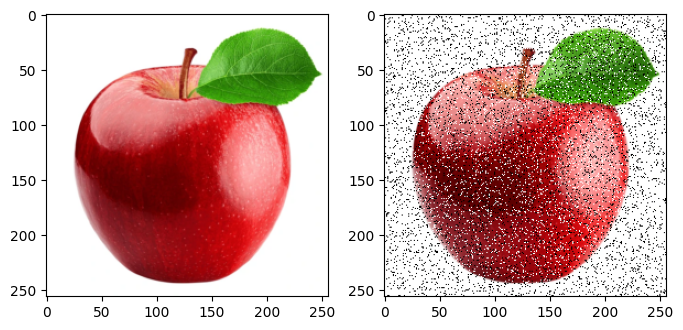

In [9]:
img_numpy=img_tensor.permute(1,2,0).numpy()
fig,axes=plt.subplots(1,2,figsize=(8,12))
axes[0].imshow(img_numpy)
img_noise=pepper_salt(img_numpy,0.2)
axes[1].imshow(img_noise)
plt.show()

## 感知损失

In [10]:
import torchvision.models as models
from torchvision.models import VGG16_Weights

In [19]:
vgg=models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)


In [12]:
print(vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [14]:
loss_net = nn.Sequential(*list(vgg.features.children())[:10])
print(loss_net)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


In [18]:
list1=[1,2,3]
print(*list1)

1 2 3
